<a href="https://colab.research.google.com/github/Subinthapa2092/naive-bayes-tickets/blob/person2-preprocessing/naive_bayes_tickets_01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### naive-bayes-tickets Project

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Step 1: Data Loading and Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/content/customer_support_tickets.csv")

# First looking the dataset
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
print(df.head(3))

(8469, 17)
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resolution               object
Customer Satisfaction Ra

In [ ]:
### Checking and couting the null dataset
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

report = pd.DataFrame({
    'null_count': null_counts,
    'null_%':     null_pct
})
print(report[report['null_count'] > 0])

## checking the duplicated if finding then removing it's
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(before, len(df))
after = len(df)
print(f"Duplicates removed: {before - after}")
print(f"Rows after: {after:,}")

                              null_count  null_%
Resolution                          5700   67.30
First Response Time                 2819   33.29
Time to Resolution                  5700   67.30
Customer Satisfaction Rating        5700   67.30
8469 8469
Duplicates removed: 0
Rows after: 8,469


In [ ]:
### droping  PII(Personally Identifiable Information) columns
pii_cols = ['Customer Name', 'Customer Email']
df.drop(columns = pii_cols, inplace=True)
print(f"Dropped: {pii_cols}")
print(f"Remaining columns ({df.shape[1]}): {df.columns.tolist()}")

Dropped: ['Customer Name', 'Customer Email']
Remaining columns (15): ['Ticket ID', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [ ]:
### Parseing  Date of Purchase
df['Date of Purchase'] = pd.to_datetime(
    df['Date of Purchase'], errors='coerce'
)

df['purchase_year']  = df['Date of Purchase'].dt.year
df['purchase_month'] = df['Date of Purchase'].dt.month
df['purchase_day']   = df['Date of Purchase'].dt.day
df['purchase_dow']   = df['Date of Purchase'].dt.dayofweek

# errors='coerce' turning bad dates into NaT, not a crash
bad = df['Date of Purchase'].isnull().sum()
print(f"Unparseable dates: {bad}")
print(f"Date range: {df['Date of Purchase'].min().date()} to {df['Date of Purchase'].max().date()}")

# Parse responsing time columns
df['First Response Time'] = pd.to_datetime(
    df['First Response Time'], errors='coerce'
)
df['Time to Resolution'] = pd.to_datetime(
    df['Time to Resolution'], errors='coerce'
)

# Extract hour of day (0–23) as numeric feature
df['first_response_hour'] = df['First Response Time'].dt.hour
df['resolution_hour']     = df['Time to Resolution'].dt.hour

# Binary flags: checking did a response/resolution happen at all?
df['has_first_response'] = df['First Response Time'].notna().astype(int)
df['is_resolved']        = df['Time to Resolution'].notna().astype(int)

print(df[['first_response_hour','has_first_response',
          'resolution_hour','is_resolved']].head(4))

Unparseable dates: 0
Date range: 2020-01-01 to 2021-12-30
   first_response_hour  has_first_response  resolution_hour  is_resolved
0                 12.0                   1              NaN            0
1                 16.0                   1              NaN            0
2                 11.0                   1             18.0            1
3                  7.0                   1              1.0            1


In [ ]:
### Handling nulls & Resolution column
# Confirming : nulls only appear in non-Closed tickets
print(df.groupby('Ticket Status')['Resolution'].apply(
    lambda x: x.isnull().sum()
))

null_before = df['Resolution'].isnull().sum()
df['Resolution'] = df['Resolution'].fillna('Pending')

print(f"Nulls before: {null_before} then after: {df['Resolution'].isnull().sum()}")

Ticket Status
Closed                          0
Open                         2819
Pending Customer Response    2881
Name: Resolution, dtype: int64
Nulls before: 5700 then after: 0


In [ ]:
# Handle nulls :-: Satisfaction Rating
# Confirm: ratings only exist for Closed tickets
print(df.groupby('Ticket Status')['Customer Satisfaction Rating'].count())

# Create flag BEFORE filling (flag the actual non-nulls)
df['satisfaction_rated_flag'] = (
    df['Customer Satisfaction Rating'].notna().astype(int)
)
df['Customer Satisfaction Rating'] = (
    df['Customer Satisfaction Rating'].fillna(0)
)

print(df['satisfaction_rated_flag'].value_counts())

Ticket Status
Closed                       2769
Open                            0
Pending Customer Response       0
Name: Customer Satisfaction Rating, dtype: int64
satisfaction_rated_flag
0    5700
1    2769
Name: count, dtype: int64


In [ ]:
#Handling nulls  response hour columns
# Filling with -1 sentinel (distinct from valid hours 0–23)
df['first_response_hour'] = (
    df['first_response_hour'].fillna(-1).astype(int)
)
df['resolution_hour'] = (
    df['resolution_hour'].fillna(-1).astype(int)
)

print(df['first_response_hour'].value_counts().sort_index().head(5))
print(f"Null check: {df['first_response_hour'].isnull().sum()} nulls remain")

first_response_hour
-1    2819
 0     240
 1     239
 2     253
 3     206
Name: count, dtype: int64
Null check: 0 nulls remain


In [ ]:
### Fixing Ticket Description placeholders
# Check the problem
has_placeholder = df['Ticket Description'].str.contains(
    r'{product_purchased}', na=False
).sum()
print(f"Rows with placeholder: {has_placeholder:,}")

# Fixing : replace placeholder with actual product name
df['Ticket Description'] = df.apply(
    lambda row: row['Ticket Description'].replace(
        '{product_purchased}', str(row['Product Purchased'])
    ) if isinstance(row['Ticket Description'], str) else row['Ticket Description'],
    axis=1
)

# Verifying fix
remaining = df['Ticket Description'].str.contains(
    r'{product_purchased}', na=False
).sum()
print(f"Remaining placeholders: {remaining}")

Rows with placeholder: 8,469
Remaining placeholders: 0


### Validating dtypes & drop raw datetime columns

In [ ]:
# Casting numeric columns to correct types
int_cols = ['Customer Age', 'Ticket ID', 'purchase_year',
            'purchase_month', 'purchase_day', 'purchase_dow']
for col in int_cols:
    df[col] = df[col].astype(int)

# Droping raw datetime columns (replaced by numeric features)
drop_cols = ['Date of Purchase',
             'First Response Time',
             'Time to Resolution']
df.drop(columns=drop_cols, inplace=True)

print(f"Remaining columns: {df.shape[1]}")
print(df.dtypes)

Remaining columns: 21
Ticket ID                         int64
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
Customer Satisfaction Rating    float64
purchase_year                     int64
purchase_month                    int64
purchase_day                      int64
purchase_dow                      int64
first_response_hour               int64
resolution_hour                   int64
has_first_response                int64
is_resolved                       int64
satisfaction_rated_flag           int64
dtype: object


### Step 3 : Cleaning and Saving whole dataset on file

In [ ]:
os.makedirs("data/processed", exist_ok=True)

output_path = "data/processed/tickets_clean.csv"
df.to_csv(output_path, index=False)

# Verifying the saved file
saved = pd.read_csv(output_path)
print(f"Saved: {output_path}")
print(f"Shape: {saved.shape}")
print(f"Nulls: {saved.isnull().sum().sum()}")
print(f"Columns: {saved.columns.tolist()}")
print(f"File size: {os.path.getsize(output_path)/1024:.1f} KB")

print("Successfully Dataset saved !")

Saved: data/processed/tickets_clean.csv
Shape: (8469, 21)
Nulls: 0
Columns: ['Ticket ID', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'Customer Satisfaction Rating', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_dow', 'first_response_hour', 'resolution_hour', 'has_first_response', 'is_resolved', 'satisfaction_rated_flag']
File size: 3468.7 KB
Successfully Dataset saved !


### Step 4: EDA on Class Distribution

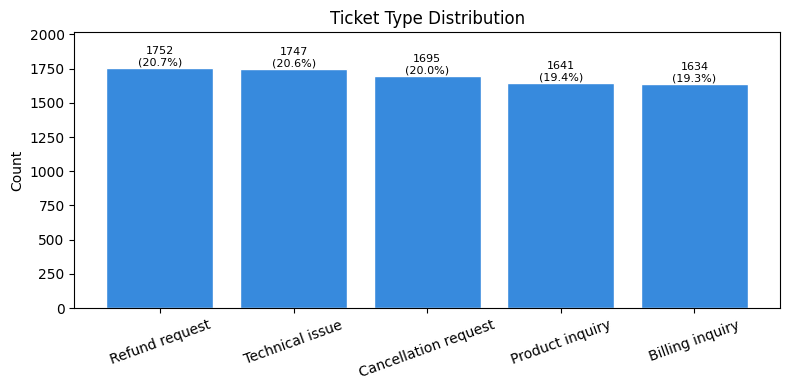

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


In [ ]:
### 1) EDA on Ticket Type Distribution
tt = df['Ticket Type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tt.index, tt.values, color='#378ADD', edgecolor='white')
ax.set_title("Ticket Type Distribution")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=20)
ax.set_ylim(0, max(tt.values) * 1.15)

for i, v in enumerate(tt.values):
    ax.text(i, v + 20, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("01_ticket_type_distribution.png", dpi=150)
plt.show()
print(tt)

=== Text Length Stats ===
count    8469.0
mean      282.0
std        44.0
min       135.0
25%       263.0
50%       290.0
75%       310.0
max       402.0
Name: text_length, dtype: float64


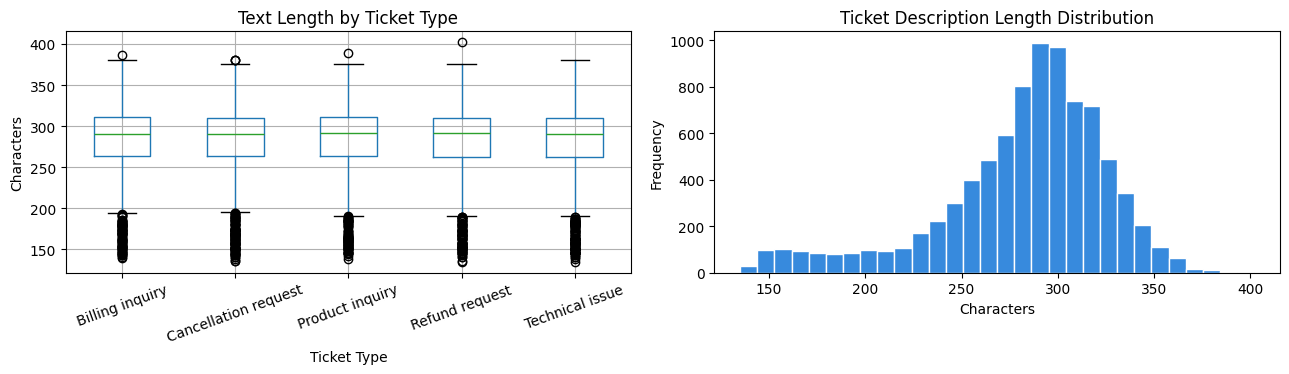

In [ ]:
 ## 2) EDA on  Ticket Description Text Length by Ticket Type
df['text_length'] = df['Ticket Description'].str.len()

print("=== Text Length Stats ===")
print(df['text_length'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot: length by ticket type
df.boxplot(column='text_length', by='Ticket Type', ax=axes[0])
axes[0].set_title("Text Length by Ticket Type")
axes[0].set_xlabel("Ticket Type")
axes[0].set_ylabel("Characters")
axes[0].tick_params(axis='x', rotation=20)

# Histogram: overall distribution
axes[1].hist(df['text_length'], bins=30, color='#378ADD', edgecolor='white')
axes[1].set_title("Ticket Description Length Distribution")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Frequency")

plt.suptitle("")
plt.tight_layout()
plt.savefig("02_text_length_analysis.png", dpi=150)
plt.show()

## Step 4: Saving clean data on the csv file

In [ ]:
import os
os.makedirs("data/processed", exist_ok=True)

nb_df = df[['Ticket Description', 'Ticket Type']].copy()
nb_df.to_csv("data/processed/tickets_nb_ready.csv", index=False)

print(f"Shape: {nb_df.shape}")
print(f"Columns: {nb_df.columns.tolist()}")
print(f"\nTicket Type counts:\n{nb_df['Ticket Type'].value_counts()}")
print("\nSaved: data/processed/tickets_nb_ready.csv ")

Shape: (8469, 2)
Columns: ['Ticket Description', 'Ticket Type']

Ticket Type counts:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Saved: data/processed/tickets_nb_ready.csv 
